# 회귀 기반 가중치 (베이스라인)

log(가입자 수)를 회귀로 설명해서 가중치를 뽑은 첫 번째 시도. 이후
`logshare_shap_weights.ipynb`에서 y를 log(시장점유율)로, 모델을 LightGBM+SHAP으로
바꿔서 다시 뽑았음 — 이 파일은 그 이전 버전과 비교할 근거로 남겨둠. 서비스 코드
(`scoring.py`)에 실제로 반영된 값도 아직 이 파일 기준임.


In [1]:
import re
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))  # scoring.py import 하려면 repo 루트가 path에 있어야 함

pd.set_option("display.max_columns", None)

plans = pd.read_csv("../data/통신요금제_통합데이터_최종.csv", dtype={"plan_id": str})
plans.shape

(2759, 42)

In [2]:
plans.head()

,carrier_type,host_mno,mvno_brand,plan_id,base_plan_id,plan_id_type,plan_name,selected_option,plan_category,is_online_only,age_condition,signup_notice,network_gen,base_data_gb,extra_data_gb,data_gb,data_unlimited,data_throttle_speed,daily_data_gb,base_tethering_gb,extra_tethering_gb,tethering_gb,tethering_support,voice_unlimited,voice_minutes,voice_extra_minutes,sms_unlimited,sms_count,monthly_fee,discounted_fee,discount_type,discount_period_months,benefit_count,ott_option_count,ott_options,membership_grade,smart_device_benefit,extra_data_benefit,gift_benefit,subscriber_count,source_url,crawled_at
0,MNO,KT,NaN,1692_초이스 더블 유튜브 프리미엄+넷플릭스,1692_초이스 더블 유튜브 프리미엄+넷플릭스,official_code,초이스 더블 유튜브 프리미엄+넷플릭스,NaN,KT-통합요금제,False,NaN,NaN,NaN,NaN,NaN,NaN,True,100Kbps,NaN,90.0,NaN,90.0,quota,True,NaN,300.0,True,NaN,120000,90000,선택약정 25% 할인,NaN,10,2,유튜브 프리미엄 | 넷플릭스,VVIP,스마트기기/데이터쉐어링 스마트기기 월정액/ 데이터쉐어링 각 1회선 할인,공유데이터 90GB,쇼핑라운지 할인 쿠폰 (5천원권),NaN,https://product.kt.com/wDic/productDetail.do?I...,2026-08-21T00:29:51.983488+00:00
1,MNO,KT,NaN,1692_초이스 더블 유튜브 프리미엄+ Google AI Plus,1692_초이스 더블 유튜브 프리미엄+ Google AI Plus,official_code,초이스 더블 유튜브 프리미엄+ Google AI Plus,NaN,KT-통합요금제,False,NaN,NaN,NaN,NaN,NaN,NaN,True,100Kbps,NaN,90.0,NaN,90.0,quota,True,NaN,300.0,True,NaN,120000,90000,선택약정 25% 할인,NaN,10,1,유튜브 프리미엄,VVIP,스마트기기/데이터쉐어링 스마트기기 월정액/ 데이터쉐어링 각 1회선 할인,공유데이터 90GB,쇼핑라운지 할인 쿠폰 (5천원권),NaN,https://product.kt.com/wDic/productDetail.do?I...,2026-08-21T00:29:51.983488+00:00
2,MNO,KT,NaN,1692_초이스 더블 유튜브 프리미엄+디바이스,1692_초이스 더블 유튜브 프리미엄+디바이스,official_code,초이스 더블 유튜브 프리미엄+디바이스,NaN,KT-통합요금제,False,NaN,NaN,NaN,NaN,NaN,NaN,True,100Kbps,NaN,90.0,NaN,90.0,quota,True,NaN,300.0,True,NaN,120000,90000,선택약정 25% 할인,NaN,10,1,유튜브 프리미엄,VVIP,디바이스 할인(최대 6천원) | 스마트기기/데이터쉐어링 스마트기기 월정액/ 데이터쉐...,공유데이터 90GB,쇼핑라운지 할인 쿠폰 (5천원권),NaN,https://product.kt.com/wDic/productDetail.do?I...,2026-08-21T00:29:51.983488+00:00
3,MNO,KT,NaN,1692_초이스 더블 디바이스,1692_초이스 더블 디바이스,official_code,초이스 더블 디바이스,NaN,KT-통합요금제,False,NaN,NaN,NaN,NaN,NaN,NaN,True,100Kbps,NaN,90.0,NaN,90.0,quota,True,NaN,300.0,True,NaN,120000,90000,선택약정 25% 할인,NaN,11,0,NaN,VVIP,디바이스 할인 (1개 or 2개 선택 가능) 1개 선택 시 최대 12천원 할인 2개...,공유데이터 90GB,쇼핑라운지 할인 쿠폰 (5천원권),NaN,https://product.kt.com/wDic/productDetail.do?I...,2026-08-21T00:29:51.983488+00:00
4,MNO,KT,NaN,1692_초이스 더블 디즈니플러스+폰케어,1692_초이스 더블 디즈니플러스+폰케어,official_code,초이스 더블 디즈니플러스+폰케어,NaN,KT-통합요금제,False,NaN,NaN,NaN,NaN,NaN,NaN,True,100Kbps,NaN,90.0,NaN,90.0,quota,True,NaN,300.0,True,NaN,120000,90000,선택약정 25% 할인,NaN,10,1,디즈니+,VVIP,스마트기기/데이터쉐어링 스마트기기 월정액/ 데이터쉐어링 각 1회선 할인,공유데이터 90GB,쇼핑라운지 할인 쿠폰 (5천원권),NaN,https://product.kt.com/wDic/productDetail.do?I...,2026-08-21T00:29:51.983488+00:00


# 1. MNO vs MVNO — 뭐가 다른가

In [3]:
# carrier_type 분포 — MNO/MVNO 비율, 학습 모집단 크기 확인
plans.carrier_type.value_counts()

carrier_type
MVNO    2203
MNO      556
Name: count, dtype: int64

In [4]:
# MNO vs MVNO — 요금·데이터·구성 차이 한눈에
num_cols = ["monthly_fee", "discounted_fee", "data_gb", "tethering_gb",
            "voice_minutes", "sms_count", "benefit_count"]
plans.groupby("carrier_type")[num_cols].describe().T

carrier_type                    MNO          MVNO
monthly_fee    count     556.000000   2203.000000
               mean    82168.093525  29714.581026
               std     33428.587533  16132.048253
               min     16500.000000    500.000000
               25%     55000.000000  16500.000000
               50%     89000.000000  29590.000000
               75%    110000.000000  42000.000000
               max    130000.000000  76000.000000
discounted_fee count     556.000000   2203.000000
               mean    63939.913669  16612.459828
               std     24203.768838  13025.142443
               min     12375.000000      0.000000
               25%     43500.000000   6600.000000
               50%     67500.000000  14900.000000
               75%     82500.000000  23325.000000
               max     97500.000000  76000.000000
data_gb        count     213.000000   2183.000000
               mean       44.739671     40.666963
               std        61.361197     48.989079
               min         0.244000      0.098000
               25%         6.000000      7.000000
               50%        15.000000     15.000000
               75%        54.000000     71.000000
               max       300.000000    300.000000
tethering_gb   count     410.000000    368.000000
               mean      100.409756     18.262228
               std        50.370247     21.908079
               min         0.000000      1.000000
               25%        80.000000      7.000000
               50%       100.000000     11.000000
               75%       120.000000     15.000000
               max       200.000000    100.000000
voice_minutes  count      13.000000   1000.000000
               mean      115.923077    235.281000
               std        46.217712    512.791317
               min         2.000000      0.000000
               25%       100.000000    100.000000
               50%       125.000000    200.000000
               75%       130.000000    300.000000
               max       180.000000   9997.000000
sms_count      count      10.000000   1036.000000
               mean      157.000000    137.277992
               std        24.966644    178.098176
               min       100.000000      0.000000
               25%       150.000000    100.000000
               50%       150.000000    100.000000
               75%       180.000000    100.000000
               max       180.000000   2000.000000
benefit_count  count     556.000000   2203.000000
               mean        5.230216      1.213345
               std         3.779635      1.566238
               min         0.000000      0.000000
               25%         2.000000      0.000000
               50%         5.000000      1.000000
               75%         9.000000      2.000000
               max        13.000000      9.000000

In [5]:
# 카테고리형 차이 — 5G 비중, 온라인전용 비중, 무제한 비중
for c in ["network_gen", "is_online_only", "data_unlimited", "voice_unlimited"]:
    print(f"--- {c} ---")
    print(plans.groupby("carrier_type")[c].value_counts(normalize=True))
    print()

--- network_gen ---
carrier_type  network_gen
MNO           5G             0.974265
              LTE            0.025735
MVNO          LTE            0.766682
              5G             0.233318
Name: proportion, dtype: float64

--- is_online_only ---
carrier_type  is_online_only
MNO           False             0.838129
              True              0.161871
MVNO          True              1.000000
Name: proportion, dtype: float64

--- data_unlimited ---
carrier_type  data_unlimited
MNO           True              0.616906
              False             0.383094
MVNO          False             0.990921
              True              0.009079
Name: proportion, dtype: float64

--- voice_unlimited ---
carrier_type  voice_unlimited
MNO           True               0.969424
              False              0.030576
MVNO          True               0.546074
              False              0.453926
Name: proportion, dtype: float64



In [6]:
# MNO 오프라인(일반) 요금제만 — 온라인전용 90개 제외
mno_offline = plans[(plans.carrier_type == "MNO") & (~plans.is_online_only)]
len(mno_offline)

466

In [7]:
mno_offline[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
monthly_fee,466.0,86994.549356,33836.202663,16500.000,58000.0,90000.0,115000.0,130000.0
discounted_fee,466.0,65245.905579,25377.158935,12375.000,43500.0,67500.0,86250.0,97500.0
data_gb,181.0,42.508011,58.447203,0.244,5.0,15.0,51.0,300.0
tethering_gb,339.0,106.064897,51.709778,0.000,80.0,100.0,140.0,200.0
voice_minutes,13.0,115.923077,46.217712,2.000,100.0,125.0,130.0,180.0
sms_count,10.0,157.000000,24.966644,100.000,150.0,150.0,180.0,180.0
benefit_count,466.0,5.461373,3.910780,0.000,2.0,5.0,9.0,13.0


**함정:** `data_gb`·`voice_minutes`·`sms_count` 의 낮은 count(181/13/10)는 결측이 아니라
**무제한이라 NaN**이다. MNO 오프라인은 데이터 61.7%, 통화 96.9%가 무제한이라 지금 describe는
유량제 요금제만 남긴 값 — 그대로 비교하면 안 된다. 상한값(scoring.py 기준: 300GB/1000분/1000건)
으로 채워야 한다.

In [8]:
# 무제한 -> 상한값 치환 (scoring.py 기준값 그대로 씀: DATA_MAX=300, VOICE_MAX=1000)
mvno = plans[plans.carrier_type == "MVNO"]
def capped(df):
    d = df.copy()
    d["data_gb_cap"] = d.data_gb.where(~d.data_unlimited, 300)
    d["voice_minutes_cap"] = d.voice_minutes.where(~d.voice_unlimited, 1000)
    d["sms_count_cap"] = d.sms_count.where(~d.sms_unlimited, 1000)
    return d

mno_offline_c = capped(mno_offline)
mvno_c = capped(mvno)
mno_offline_c[["data_gb_cap", "voice_minutes_cap", "sms_count_cap"]].describe().T

,count,mean,std,min,25%,50%,75%,max
data_gb_cap,466.0,199.987017,130.790549,0.244,30.25,300.0,300.0,300.0
voice_minutes_cap,462.0,975.123377,146.546817,2.000,1000.00,1000.0,1000.0,1000.0
sms_count_cap,452.0,981.349558,124.181371,100.000,1000.00,1000.0,1000.0,1000.0


In [9]:
# 이제 MNO vs MVNO 제대로 비교 (무제한 반영)
cap_cols = ["data_gb_cap", "voice_minutes_cap", "sms_count_cap", "tethering_gb", "discounted_fee"]
pd.concat({"MNO_offline": mno_offline_c[cap_cols].describe(),
           "MVNO": mvno_c[cap_cols].describe()}, axis=1)

MNO_offline                                                              \
      data_gb_cap voice_minutes_cap sms_count_cap tethering_gb discounted_fee   
count  466.000000        462.000000    452.000000   339.000000     466.000000   
mean   199.987017        975.123377    981.349558   106.064897   65245.905579   
std    130.790549        146.546817    124.181371    51.709778   25377.158935   
min      0.244000          2.000000    100.000000     0.000000   12375.000000   
25%     30.250000       1000.000000   1000.000000    80.000000   43500.000000   
50%    300.000000       1000.000000   1000.000000   100.000000   67500.000000   
75%    300.000000       1000.000000   1000.000000   140.000000   86250.000000   
max    300.000000       1000.000000   1000.000000   200.000000   97500.000000   

              MVNO                                                              
       data_gb_cap voice_minutes_cap sms_count_cap tethering_gb discounted_fee  
count  2203.000000       2203.000000   2203.000000   368.000000    2203.000000  
mean     43.021325        652.873808    594.289605    18.262228   16612.459828  
std      54.620764        514.120827    447.668784    21.908079   13025.142443  
min       0.098000          0.000000      0.000000     1.000000       0.000000  
25%       7.000000        200.000000    100.000000     7.000000    6600.000000  
50%      15.000000       1000.000000   1000.000000    11.000000   14900.000000  
75%      71.000000       1000.000000   1000.000000    15.000000   23325.000000  
max     300.000000       9997.000000   2000.000000   100.000000   76000.000000

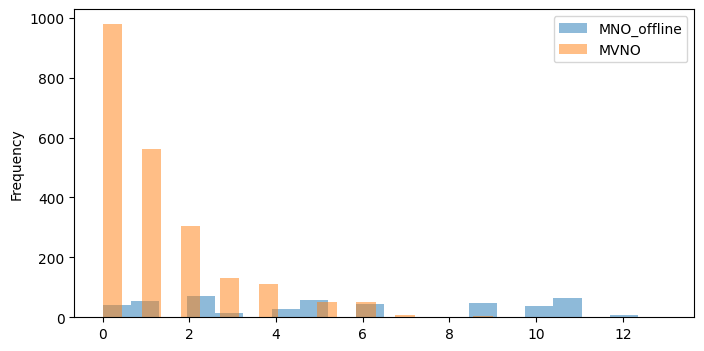

In [10]:
# 혜택 개수 — MNO는 멤버십 위주라 적을 거란 가설 확인
fig, ax = plt.subplots(figsize=(8, 4))
mno_offline.benefit_count.plot(kind="hist", bins=20, alpha=0.5, label="MNO_offline", ax=ax)
mvno.benefit_count.plot(kind="hist", bins=20, alpha=0.5, label="MVNO", ax=ax)
ax.legend()

In [11]:
# OTT 옵션 개수 — scoring.py가 OTT 시장가를 축으로 쓰니 분포 확인
mno_offline.ott_option_count.describe(), mvno.ott_option_count.describe()

(count    466.000000
 mean       0.246781
 std        0.451092
 min        0.000000
 25%        0.000000
 50%        0.000000
 75%        0.000000
 max        2.000000
 Name: ott_option_count, dtype: float64,
 count    2203.000000
 mean        0.019973
 std         0.174591
 min         0.000000
 25%         0.000000
 50%         0.000000
 75%         0.000000
 max         2.000000
 Name: ott_option_count, dtype: float64)

In [12]:
# 프로모션 기간 — 선택약정(기간 없음) vs 공시지원/첫달할인(기간 있음) 비율
for name, g in [("MNO_offline", mno_offline), ("MVNO", mvno)]:
    print(f"--- {name} ---")
    print(g.discount_period_months.describe())
    print("결측(=선택약정 등 기간무관) 비율:", g.discount_period_months.isna().mean())
    print()

--- MNO_offline ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: discount_period_months, dtype: float64
결측(=선택약정 등 기간무관) 비율: 1.0

--- MVNO ---
count    1543.000000
mean       10.569669
std         6.879652
min         3.000000
25%         7.000000
50%         7.000000
75%        12.000000
max        36.000000
Name: discount_period_months, dtype: float64
결측(=선택약정 등 기간무관) 비율: 0.29959146618247845



## Part 1 결론 — 같은 잣대로 못 비교하는 두 상품군

요금은 MVNO 실부담 중앙값 14,900원, MNO 오프라인 67,500원 — MNO의 1/4. 세대는 MNO가
5G 97.4%, MVNO는 아직 LTE가 76.7%로 주류. 무제한 비중도 갈린다 — MNO는 데이터
61.7%·통화 96.9%가 무제한인데, MVNO는 데이터 무제한이 0.9%뿐이고 통화도 45.7%가
유량제다. 테더링은 중앙값 MNO 100GB, MVNO 11GB로 9배 차이. 혜택 개수는 MNO 평균
5.46개, MVNO 평균 1.22개.

프로모션 구조도 다르다. MNO 오프라인은 discount_period_months가 100% 결측(선택약정류라
기간 무관), MVNO는 70%가 기간이 있고(중앙값 7개월) "첫 N개월 할인 후 정가 복귀"가
흔하다. scoring.py가 정가 대신 6개월 실부담(COMPARE_MONTHS)으로 줄 세우는 이유가
여기 있다.

MVNO는 저가·유량제·혜택빈약·기간한정형, MNO는 고가·무제한·혜택풍부·정가고정형 — 서로
다른 상품군이라 같은 축으로 비교할 근거가 약하다. scoring.py가 MVNO만 학습 모집단으로
쓰는 것과 일치한다.


# 2. MVNO 뜯어보기 — 혜택은 택1인가, 쓸모있나

In [13]:
# 혜택상세 로드, MVNO 플랜에 걸리는 행만
benefits = pd.read_csv("../data/통신요금제_혜택상세_최종.csv", dtype={"plan_id": str})
bm = benefits[benefits.plan_id.isin(set(mvno.plan_id))]
print(f"MVNO 혜택 행: {len(bm)} / 플랜 {mvno.plan_id.nunique()}개 중 혜택 보유 {bm.plan_id.nunique()}개")
bm.benefit_category.value_counts()

MVNO 혜택 행: 2673 / 플랜 2203개 중 혜택 보유 1224개


benefit_category
사은품/페이백     1792
추가데이터        413
도서/콘텐츠       220
교육/AI서비스     102
영상/OTT        44
기타            42
멤버십           18
스마트기기         18
제휴서비스         15
음악/오디오         8
복합/선택혜택        1
Name: count, dtype: int64

In [14]:
# 택1(is_selectable/select_group) 구조가 MVNO 데이터에 실제로 잡히는지
bm.is_selectable.value_counts(dropna=False)

is_selectable
False    2673
Name: count, dtype: int64

In [15]:
# OTT — 커버리지와 플랜당 스택 개수 (2개 이상이면 "전부 제공"인지 "택1 오게재"인지 의심)
_ott_prices = pd.read_csv("../data/ott_prices.csv")
ott = bm[bm.benefit_service.isin(_ott_prices.service)]  # 카테고리명이 영상/OTT·음악/오디오 등으로 쪼개져서(2026-09-16 크롤러 수정) 서비스명 매칭으로 변경
print(f"OTT 보유 플랜: {ott.plan_id.nunique()} / {mvno.plan_id.nunique()} "
      f"({ott.plan_id.nunique() / mvno.plan_id.nunique():.1%})")
ott_cnt = ott.groupby("plan_id").size()
ott_cnt.describe()

OTT 보유 플랜: 119 / 2203 (5.4%)


count    119.000000
mean       1.117647
std        0.348762
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
dtype: float64

In [16]:
# scoring.py 주석: mvno_brand가 SKT/KT/LG U+ 인 45개(실은 MNO 온라인전용이 잘못 분류된 것)가
# OTT 이중계산 버그의 유일한 발생지라고 함 - 실제로 그런지 숫자로 확인
misfit = mvno[mvno.mvno_brand.isin(["SKT", "KT", "LG U+"])]
multi_ott_ids = ott_cnt[ott_cnt >= 2].index
print("OTT 2개+ 스택된 플랜:", len(multi_ott_ids))
print("그중 45개(오분류) 안에 있는 것:", misfit.plan_id.isin(multi_ott_ids).sum(), "/", len(misfit))

OTT 2개+ 스택된 플랜: 13
그중 45개(오분류) 안에 있는 것: 13 / 45


In [17]:
# 카테고리별 쓸모 판단 — 커버리지 낮으면 축으로 못 쓴다
plan_n = mvno.plan_id.nunique()
summary = bm.groupby("benefit_category").agg(
    플랜수=("plan_id", "nunique"),
    평균시장가원=("benefit_value_won", "mean"),
)
summary["커버리지(%)"] = (summary["플랜수"] / plan_n * 100).round(1)
summary

,플랜수,평균시장가원,커버리지(%)
benefit_category,,,
교육/AI서비스,51,NaN,2.3
기타,42,NaN,1.9
도서/콘텐츠,217,10342.857143,9.9
멤버십,18,NaN,0.8
복합/선택혜택,1,NaN,0.0
사은품/페이백,1076,27264.244426,48.8
스마트기기,17,12000.000000,0.8
영상/OTT,32,9700.000000,1.5
음악/오디오,8,NaN,0.4


In [18]:
# OTT 카테고리, 서비스명 없는 행이 얼마나 되나 - 결측인지 다른 종류 혜택인지 확인
unmapped = ott[ott.benefit_service.isna()]
print(f"OTT 행 {len(ott)}개 중 서비스명 NaN: {len(unmapped)}개 ({len(unmapped) / len(ott):.1%})")
unmapped.benefit_name.value_counts().head(10)

OTT 행 133개 중 서비스명 NaN: 0개 (0.0%)


Series([], Name: count, dtype: int64)

In [19]:
# NaN 행 2개가 같이 뜨는 플랜 - 택1(대체재)인지 각각 다 주는 건지 원본으로 확인
two_row_ids = unmapped.groupby("plan_id").filter(lambda g: len(g) == 2).plan_id.unique()[:3]
bm[bm.plan_id.isin(two_row_ids)][
    ["plan_id", "benefit_category", "benefit_name", "is_selectable", "select_group"]
].sort_values("plan_id")

,plan_id,benefit_category,benefit_name,is_selectable,select_group


In [20]:
# 서비스명이 살아있는(=실제로 점수에 반영되는) 진짜 OTT 커버리지
valid_ott = ott[ott.benefit_service.notna()]
print(f"실제 유효 OTT 보유 플랜: {valid_ott.plan_id.nunique()} / {plan_n} "
      f"({valid_ott.plan_id.nunique() / plan_n:.1%})  "
      f"— 카테고리 기준 {ott.plan_id.nunique()}개보다 훨씬 적다")

실제 유효 OTT 보유 플랜: 119 / 2203 (5.4%)  — 카테고리 기준 119개보다 훨씬 적다


## Part 2 결론 — 택1 아니라 "전부 제공", 카테고리는 영상 OTT보다 넓다

(아래 수치는 최종 학습 모집단인 MVNO 2,158개, 즉 오분류 45개 제외 기준이다. Part 2를
쓴 시점엔 이 제외를 아직 안 해서 2,203개 기준 수치가 적혀 있었다 — 회귀 학습 자체는
처음부터 2,158개로 맞게 했지만, 이 결론 문단의 숫자만 낡아 있었다.)

택1 구조는 메타데이터에 없다 — is_selectable이 MVNO 혜택 전부 False다. "1개
할인" 같은 문구는 자유텍스트에만 남아서 이 컬럼으로 택1을 걸러낼 수 없다.

이중계산은 이미 코드가 막아놨다. OTT 2개 이상 스택된 플랜 중 정확히 13개가 scoring.py가
학습에서 뺀 45개(온라인전용 오분류) 안에 있는데, ott_services를 sorted(set(...))로
만들어서 실제로 돌려보면 겹산정 없이 정상 계산된다. 45개를 뺀 진짜 이유는 이중계산
방지가 아니라 학습 모집단을 서빙 모집단과 브랜드 기준으로 맞추는 것에 가깝다.

OTT/구독 카테고리는 영상 스트리밍만이 아니다. 서비스명이 NaN인 213행(OTT의 69.8%)은
결측이 아니라 조선일보 구독, AI 모의고사, 크레마클럽 같은 영상이 아닌 구독형 혜택이다 —
같은 플랜 안에 두 줄이 같이 떠도 서로 대체재가 아니라 각각 다 지급되는 걸로 읽힌다.
ott_prices.csv엔 영상 OTT 시장가만 있어서 이런 행은 매핑 없이 0원 처리된다 —
scoring.py 결과 자체는 안 바뀌지만, ott_option_count 같은 개수 기준으론 영상 OTT
보유율이 과대평가된다. 실제 영상 OTT 보유 플랜은 92개(4.3%)로, 카테고리 기준
253개(11.7%)의 절반 이하다.

혜택 대부분은 값이 아니라 사은품이다 — 사은품/페이백이 전체 혜택 행의 71%(1,793/2,511)를
차지하지만 일회성이라 반복가치가 없고, scoring.py가 svc_benefit_count 계산에서 이
카테고리를 빼는 게 맞다. 반복가치 있는 축은 결국 영상 OTT뿐이고 그마저 4.3% 커버리지,
멤버십·스마트기기는 0.8%로 더 적어 축으로 못 쓴다 — WEIGHTS에 이 둘이 없는 것과
일치한다. 3개 카테고리를 기준별로 다시 짚은 상세 확인은 benefit_axis_selection.ipynb
참고.


# 3. 회귀분석 — 가중치 도출

점수 함수 $\text{score}_j = \sum_a w_a x_{aj}$ 의 가중치 $w$ 를 구한다. y = log(누적
가입자 수). 절차: 원본에서 바로 읽히는 변수 7개로 시작 → 0~1 정규화 → 회귀(브랜드
고정효과 통제) → 음수 계수 제거 → 남은 계수를 정규화해 가중치로.

In [21]:
# OTT 시장가표 로드 (plans/benefits 는 이미 로드돼있음, sys.path 는 맨 위 셀에서 설정)
prices = pd.read_csv("../data/ott_prices.csv")
price_map = dict(zip(prices.service, prices.monthly_won.astype(int)))
print(f"OTT 가격표 {len(prices)}개")

OTT 가격표 13개


## 3-1. 학습 모집단 — 오분류 45개를 뺀다

Part 2에서 본 대로 `carrier_type=MVNO`인데 `mvno_brand`가 SKT/KT/LG U+인 45개는
실은 통신 3사 온라인 전용 상품이다. 요금제 수로는 2%지만 가입자 가중치로는 14.5%.
이중계산은 이미 `set()`으로 막혀 있으니(Part 2 결론) 빼는 이유는 순수하게
**학습 모집단(진짜 알뜰폰)을 서빙 모집단과 브랜드 기준으로 맞추기 위해서**다.

In [22]:
mvno_all = plans[plans.carrier_type == "MVNO"].copy()
MNO_BRANDS = ["SKT", "KT", "LG U+", "LGU+"]
mislabeled = mvno_all.mvno_brand.isin(MNO_BRANDS)

print(f"알뜰폰 전체 {len(mvno_all):,}개 -> 오분류 45개 제외 -> {(~mislabeled).sum():,}개")
print(f"  오분류 45개의 가입자 비중: "
      f"{mvno_all.loc[mislabeled, 'subscriber_count'].sum() / mvno_all.subscriber_count.sum():.1%}")

mvno = mvno_all[~mislabeled].copy()

알뜰폰 전체 2,203개 -> 오분류 45개 제외 -> 2,158개
  오분류 45개의 가입자 비중: 14.5%


## 3-2. 변수 7개 — 원본 컬럼을 최소한만 가공한다

원본 그대로 못 쓰는 것만 손댄다: `data_gb`는 무제한·일일제공형이 NaN이라 플래그와
추가데이터를 합쳐야 하고, `data_throttle_speed`는 문자열이라 숫자로 파싱해야 한다.
`voice`/`sms`도 무제한 플래그를 값으로 바꾼다. 비용은 정가가 아니라 프로모션 기간을
반영한 6개월 실부담(`cost6`, scoring.py와 동일 기준)을 쓴다.

**혜택은 개수가 아니라 OTT 시장가(원)로.** Part 2에서 본 대로 `OTT/구독` 카테고리엔
비-영상 구독도 섞여있지만, 시장가 매핑이 안 되는 건 자동으로 0원 처리되니 그대로 둔다.

In [23]:
def qos_mbps(value):
    if pd.isna(value):
        return 0.0
    m = re.match(r"([\d.]+)\s*(kbps|mbps)", str(value).strip().lower().replace(" ", ""))
    if not m:
        return 0.0
    n = float(m.group(1))
    return n / 1000 if m.group(2) == "kbps" else n


def build(df):
    d = df.copy()
    period = np.where(d.discount_type.astype(str).str.contains("선택약정"),
                      6, d.discount_period_months.fillna(0))
    period = np.minimum(period, 6)
    d["cost6"] = (d.discounted_fee * period + d.monthly_fee * (6 - period)) / 6

    extra = benefits[benefits.benefit_category == "추가데이터"].copy()
    extra["gb"] = extra.benefit_name.fillna("").str.extract(r"([\d.]+)\s*GB", flags=re.I)[0].astype(float)
    d["extra_gb"] = d.plan_id.map(extra.groupby("plan_id").gb.sum()).fillna(0)
    d["data_total_gb"] = np.where(
        d.data_unlimited, 300,
        (d.data_gb.fillna(d.daily_data_gb.fillna(0) * 30) + d.extra_gb).clip(0, 300)
    )
    d["qos"] = d.data_throttle_speed.map(qos_mbps)
    d["tether_gb"] = d.tethering_gb.fillna(0)
    d["voice_min"] = np.where(d.voice_unlimited, 1000, d.voice_minutes.fillna(0)).clip(0, 1000)
    d["sms_cnt"] = np.where(d.sms_unlimited, 1000, d.sms_count.fillna(0)).clip(0, 1000)

    ott_b = benefits[benefits.benefit_service.isin(price_map)]  # 카테고리명이 바뀌어(2026-09-16 크롤러 수정) 서비스명 매칭으로 변경
    ott_services = d.plan_id.map(
        ott_b.groupby("plan_id")["benefit_service"].apply(lambda v: sorted(set(v.dropna())))
    )
    d["ott_value"] = ott_services.apply(
        lambda services: sum(price_map.get(s, 0) for s in services) if isinstance(services, list) else 0
    )
    return d


mvno = build(mvno)
VARS = ["cost6", "data_total_gb", "qos", "tether_gb", "voice_min", "sms_cnt", "ott_value"]
mvno[VARS].describe().T[["mean", "std", "min", "max"]].round(1)

,mean,std,min,max
cost6,15963.9,11914.2,0.0,57200.0
data_total_gb,42.9,50.0,0.1,250.0
qos,2.0,2.1,0.0,10.0
tether_gb,3.0,11.1,0.0,100.0
voice_min,631.3,416.0,0.0,1000.0
sms_cnt,583.0,442.7,0.0,1000.0
ott_value,480.2,2295.9,0.0,11900.0


## 3-2-1. 축과 y 관계를 산점도로 먼저 확인

회귀 돌리기 전에 변수 하나하나가 log(가입자수)랑 실제로 관계가 있는지, 있다면 어떤
모양인지 안 봤음. `logshare_shap_weights.ipynb`에서 log_share 기준으로 확인한 것과
같은 방식으로 여기서도 확인한다 — 점 2,158개가 겹쳐서 안 보이니 15구간(qcut)으로
나눠 구간 평균을 빨간 선으로 얹는다.


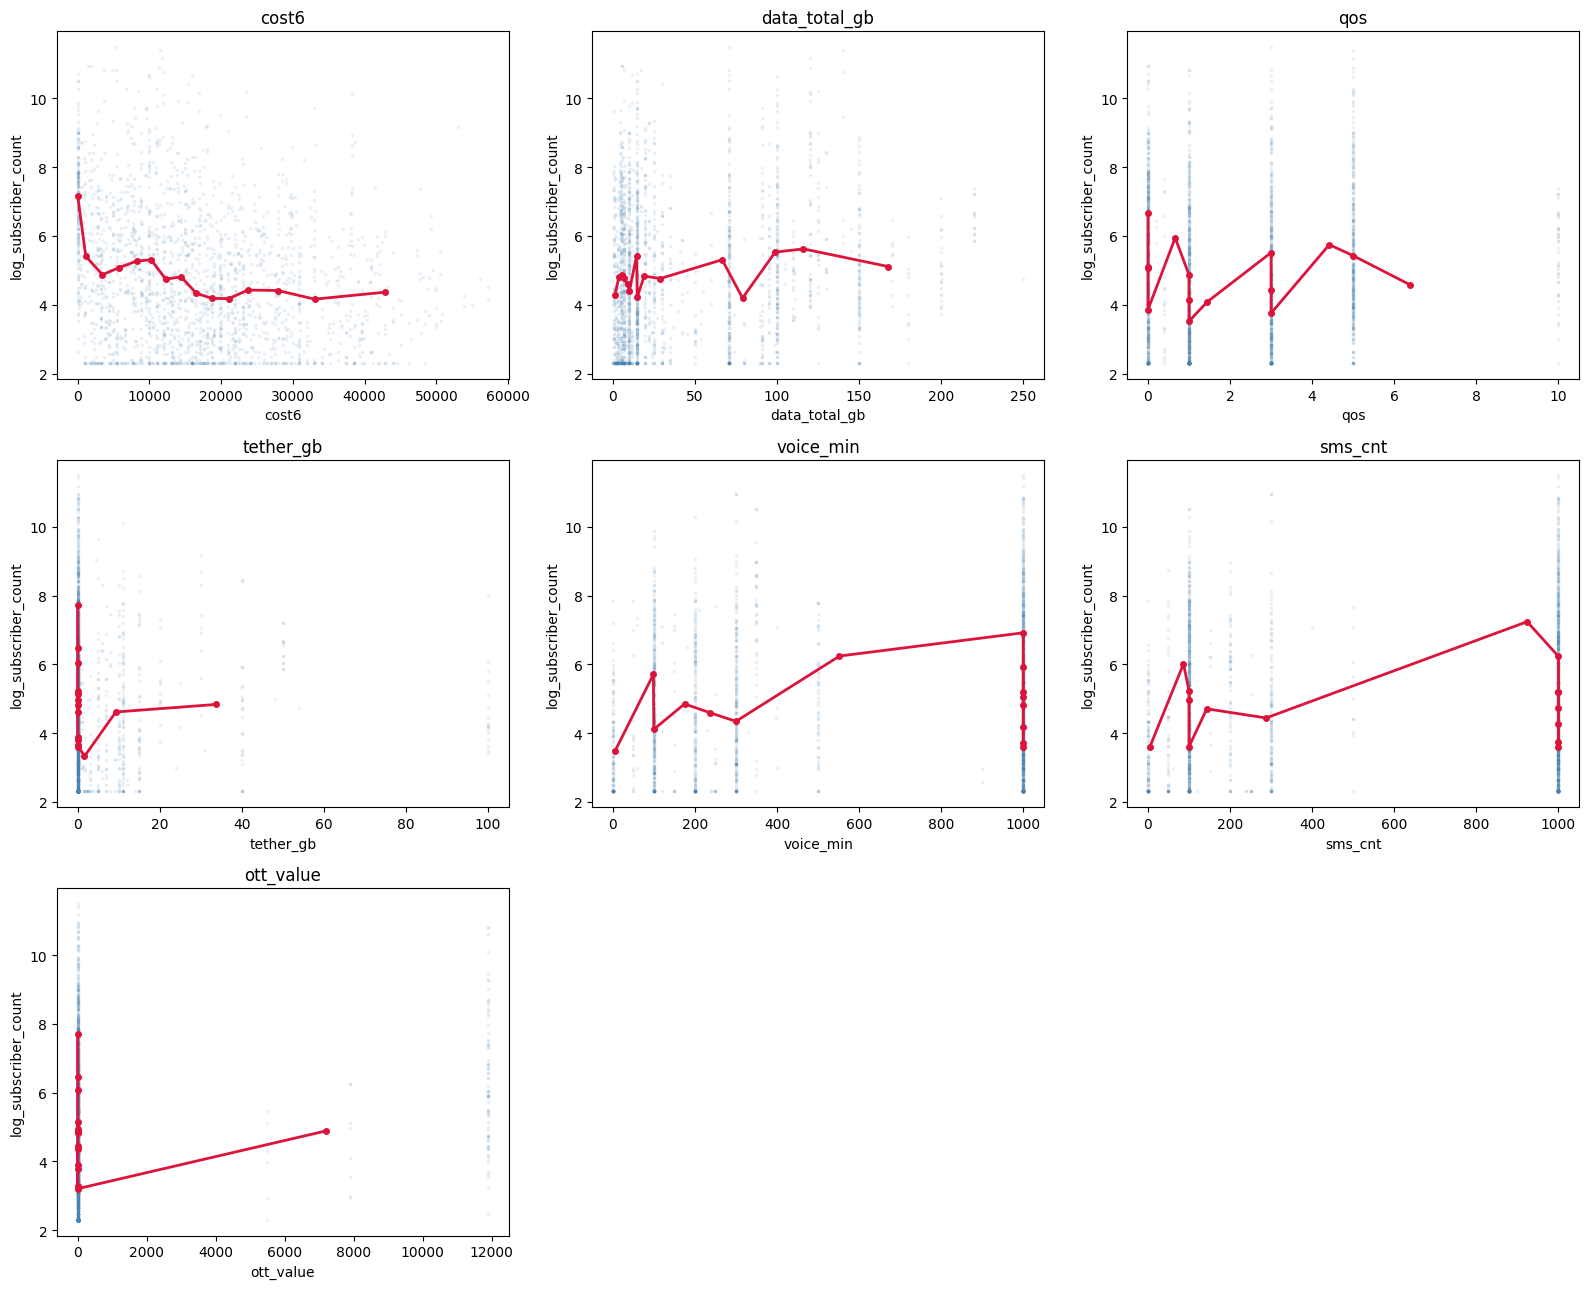

In [24]:
y_log_count = np.log(mvno.subscriber_count.values)

fig, grid = plt.subplots(3, 3, figsize=(16, 13))
grid = grid.flatten()
for i, col in enumerate(VARS):
    ax = grid[i]
    x = mvno[col].values
    ax.scatter(x, y_log_count, s=6, alpha=0.12, color="steelblue", linewidths=0)

    bins = pd.qcut(pd.Series(x).rank(method="first"), q=15, duplicates="drop")
    binned = pd.DataFrame({"x": x, "y": y_log_count, "bin": bins}).groupby("bin", observed=True).agg(
        x_mean=("x", "mean"), y_mean=("y", "mean")
    )
    ax.plot(binned.x_mean, binned.y_mean, color="crimson", linewidth=2, marker="o", markersize=4)
    ax.set_xlabel(col)
    ax.set_ylabel("log_subscriber_count")
    ax.set_title(col)
for j in range(len(VARS), len(grid)):
    fig.delaxes(grid[j])
plt.tight_layout()
plt.savefig("scatter_raw_vs_logcount.png", dpi=110)
plt.show()


## 3-3. 0~1로 정규화

비용은 방향을 뒤집는다(쌀수록 1). 모든 축이 "높을수록 좋다"로 통일돼야 계수를
서로 비교할 수 있다. y는 log(가입자 수), 브랜드 고정효과로 통제한다.

In [25]:
SCALE = {
    "cost6": 76000, "data_total_gb": 300, "qos": 10, "tether_gb": 100,
    "voice_min": 1000, "sms_cnt": 1000, "ott_value": 20000,
}
FLIP = {"cost6"}


def normalize(d, cols):
    out = pd.DataFrame(index=d.index)
    for c in cols:
        x = (d[c].astype(float) / SCALE[c]).clip(0, 1)
        out[c] = (1 - x) if c in FLIP else x
    return out


X = normalize(mvno, VARS)
y = np.log(mvno.subscriber_count.values)
brand_fe = pd.get_dummies(mvno.mvno_brand, dummy_na=True).astype(float).values
print(f"학습 표본 {len(X):,}개 · 관측 선택 {mvno.subscriber_count.sum():,.0f}건")

학습 표본 2,158개 · 관측 선택 2,705,499건


## 3-4. 상관·VIF 확인 (지울 근거인지 판단용이지, 자동 제거 기준 아님)

In [26]:
corr = X.corr()
print("|r| >= 0.5 인 쌍")
cols = list(corr.columns)
found = False
for i, a in enumerate(cols):
    for b in cols[i + 1:]:
        r = corr.loc[a, b]
        if abs(r) >= 0.5:
            print(f"   {a:<14} <-> {b:<14} r = {r:+.3f}")
            found = True
if not found:
    print("   없음")

|r| >= 0.5 인 쌍
   cost6          <-> data_total_gb  r = -0.628
   cost6          <-> qos            r = -0.626
   data_total_gb  <-> qos            r = +0.878
   voice_min      <-> sms_cnt        r = +0.943


In [27]:
def vif(frame):
    out = {}
    for c in frame.columns:
        others = frame.drop(columns=[c]).values
        A = np.column_stack([np.ones(len(frame)), others])
        b, *_ = np.linalg.lstsq(A, frame[c].values, rcond=None)
        resid = frame[c].values - A @ b
        ss = ((frame[c].values - frame[c].mean()) ** 2).sum()
        r2 = 1 - (resid ** 2).sum() / ss if ss > 0 else 0.0
        out[c] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(out).sort_values(ascending=False)


# 10 넘으면 위험 신호. 넘겨도 그 자체로 빼는 근거는 아니고, 계수 부호/유의성이
# 흔들리는지까지 봐야 한다 (사실 이번 7개는 다 무난히 통과한다).
vif(X).round(2)

sms_cnt          10.12
voice_min         9.70
data_total_gb     5.17
qos               4.95
cost6             1.87
tether_gb         1.10
ott_value         1.04
dtype: float64

## 3-5. 회귀 + 음수 계수 제거

절댓값을 씌우면 안 된다 — "많을수록 가입자가 적다"가 "많을수록 좋다"로 뒤집힌다.
하나 빼면 남은 계수가 바뀌므로 음수가 없어질 때까지 반복한다. (상관·VIF가 아니라
**부호**가 유일한 제거 기준이다.)

In [28]:
def ols(X, y, fe, label=None):
    A = np.column_stack([np.ones(len(X)), X.values, fe])
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    resid = y - A @ beta
    r2 = 1 - (resid ** 2).sum() / ((y - y.mean()) ** 2).sum()
    dof = max(len(X) - A.shape[1], 1)
    se = np.sqrt(np.diag((resid ** 2).sum() / dof * np.linalg.pinv(A.T @ A)))[1:1 + X.shape[1]]
    coef = beta[1:1 + X.shape[1]]
    table = pd.DataFrame({"계수": coef, "표준오차": se, "t": coef / se}, index=X.columns)
    if label:
        print(f"[{label}]  R2 = {r2:.4f}")
        print(table.round(3).sort_values("계수", ascending=False).to_string())
        print()
    return table, r2


axes = list(VARS)
while True:
    tab, r2 = ols(X[axes], y, brand_fe)
    neg = tab.index[tab["계수"] < 0].tolist()
    if not neg:
        break
    worst = tab.loc[neg, "계수"].idxmin()
    print(f"제외: {worst}  (계수 {tab.loc[worst, '계수']:+.3f})")
    axes.remove(worst)

print()
tab, r2 = ols(X[axes], y, brand_fe, "최종 축")

제외: sms_cnt  (계수 -0.903)

[최종 축]  R2 = 0.3977
                  계수   표준오차       t
cost6          8.626  0.329  26.230
data_total_gb  4.453  0.464   9.594
ott_value      1.407  0.309   4.560
qos            1.168  0.358   3.260
tether_gb      1.056  0.334   3.159
voice_min      0.547  0.104   5.242



## 3-6. 최종 가중치

In [29]:
w = (tab["계수"] / tab["계수"].sum()).sort_values(ascending=False)
for name, value in w.items():
    print(f"   {name:<14} {value:.3f}   (계수 {tab.loc[name, '계수']:+.3f}, t {tab.loc[name, 't']:+.2f})")
print()
print(f"합계 {w.sum():.3f} · R2 {r2:.4f}")

   cost6          0.500   (계수 +8.626, t +26.23)
   data_total_gb  0.258   (계수 +4.453, t +9.59)
   ott_value      0.082   (계수 +1.407, t +4.56)
   qos            0.068   (계수 +1.168, t +3.26)
   tether_gb      0.061   (계수 +1.056, t +3.16)
   voice_min      0.032   (계수 +0.547, t +5.24)

합계 1.000 · R2 0.3977


### 3-6-1. 안정적인가 — 부트스트랩

요금제를 복원추출로 60번 다시 뽑아 재추정한다.

In [30]:
rng = np.random.default_rng(0)
Xa = X[axes]
samples = []
for _ in range(60):
    rows = rng.choice(len(Xa), size=len(Xa), replace=True)
    t, _ = ols(Xa.iloc[rows], y[rows], brand_fe[rows])
    c = t["계수"].clip(lower=0)
    samples.append(c / c.sum() if c.sum() > 0 else c)

boot = pd.DataFrame(samples)
summary = pd.DataFrame({
    "추정치": w, "부트 평균": boot.mean(), "표준편차": boot.std(),
    "2.5%": boot.quantile(0.025), "97.5%": boot.quantile(0.975),
}).reindex(w.index)
print(summary.round(3).to_string())

order = list(w.index)
top2 = sum(1 for _, r in boot.iterrows() if set(r.nlargest(2).index) == set(order[:2]))
exact = sum(1 for _, r in boot.iterrows() if list(r.sort_values(ascending=False).index) == order)
print()
print(f"상위 2축 유지: {top2}/60 ({top2/60:.0%})")
print(f"전체 순서 완전일치: {exact}/60 ({exact/60:.0%})")

                 추정치  부트 평균   표준편차   2.5%  97.5%
cost6          0.500  0.499  0.014  0.473  0.530
data_total_gb  0.258  0.260  0.021  0.217  0.298
ott_value      0.082  0.081  0.020  0.046  0.118
qos            0.068  0.067  0.016  0.035  0.093
tether_gb      0.061  0.062  0.019  0.027  0.096
voice_min      0.032  0.031  0.006  0.018  0.042

상위 2축 유지: 60/60 (100%)
전체 순서 완전일치: 21/60 (35%)


### 3-6-2. cost6 대신 discounted_fee 를 썼으면?

정가가 아니라 프로모션가 그대로 쓰면 "곧 오를 10원 요금제"가 학습을 왜곡할까 걱정
됐었다. 실제로 재보면 학습 통계에는 거의 영향 없다 — 문제는 순위를 매기는 **적용**
단계에서만 터진다. scoring.py 가 서빙에 cost6 를 쓰는 이상, 학습도 cost6 로 맞춰야
학습/서빙 기준이 어긋나지 않는다.

In [31]:
diff = (mvno.discounted_fee != mvno.cost6).sum()
print(f"discounted_fee != cost6 인 요금제: {diff}개 / {len(mvno)} ({diff/len(mvno):.1%})")
print(f"상관계수: {mvno.discounted_fee.corr(mvno.cost6):.4f}")

discounted_fee != cost6 인 요금제: 45개 / 2158 (2.1%)
상관계수: 0.9996


### 3-6-3. 사은품/페이백을 변수로 넣지 않는 이유

`benefit_value_won`을 그대로 합치면 안 된다 — 같은 혜택이 채널별로 문구만 바꿔
중복 나열된다(아래 확인). 정확 문자열 매칭(`set()`)으로도 못 걸러낸다.

In [32]:
# 사은품 채널별 중복 나열 실제 사례 - 텍스트만 다르고 같은 혜택
cb = benefits[(benefits.benefit_category == "사은품/페이백") & benefits.plan_id.isin(set(mvno.plan_id))]
worst = cb.groupby("plan_id").size().idxmax()
cb[cb.plan_id == worst][["benefit_name", "benefit_value_won"]]

,benefit_name,benefit_value_won
4356,3대마트 상품권/네이버페이 1만원 증정,10000.0
4357,3대마트 상품권/네이버페이 1만원 증정,10000.0
4358,마트 상품권/네이버페이 1만원 증정,10000.0
4359,마트 상품권/네이버페이 1만원 증정,10000.0
4360,CU 오프라인 점포 결제시 20% 할인 제공,NaN
4361,"올리브영 12개월간 매월 5,000원 상품권",5000.0


### 3-6-4. 45개를 포함했으면 어떻게 달랐을까 (참고용)

In [33]:
included = build(mvno_all.copy())
Xi = normalize(included, VARS)
yi = np.log(included.subscriber_count.values)
fei = pd.get_dummies(included.mvno_brand, dummy_na=True).astype(float).values
ti, r2i = ols(Xi[axes], yi, fei)
wi = ti["계수"] / ti["계수"].sum()

cmp = pd.DataFrame({"45개 제외(채택)": w, "45개 포함": wi}).reindex(w.index)
cmp["차이"] = (cmp["45개 제외(채택)"] - cmp["45개 포함"]).round(3)
print(cmp.round(3).to_string())
print()
print(f"R2  제외 {r2:.4f}  vs  포함 {r2i:.4f}")

               45개 제외(채택)  45개 포함     차이
cost6               0.500   0.500 -0.000
data_total_gb       0.258   0.264 -0.006
ott_value           0.082   0.081  0.000
qos                 0.068   0.064  0.004
tether_gb           0.061   0.060  0.002
voice_min           0.032   0.031  0.000

R2  제외 0.3977  vs  포함 0.4068


## 3-7. scoring.py 대조 -- 이 저장소에는 없음

test2의 scoring.py(연구용 프로토타입)와 가중치가 일치하는지 확인하던 절인데, 이 저장소는 그 모듈이 없고 실제 스코어링은 agent/mcda.py의 SMAA-2다. 이 노트북에서 뽑은 가중치는 agent/weight_bootstrap.json으로 옮겨져 거기서 쓰인다.


## 4. 정리

변수 30개가 아니라 7개로 시작해도 결론은 같다 — 원본에서 자연스럽게 나오는 변수만
넣으면 서로 겹치는 쌍이 없어 상관·VIF 정리가 거의 필요 없다. 상관 높다고 자동으로
빼지도 않았다 — cost6·data·qos, voice·sms는 다 상관 0.5 이상이지만 VIF가 전부 10
미만이라 그대로 뒀고, 뺀 기준은 상관이 아니라 회귀 부호(음수 = sms_cnt 하나)였다.

혜택은 개수가 아니라 시장가(원)로 넣었더니 t값이 개수(2.6) 대비 거의 두 배(4.9)로
뚜렷해졌다. 비용은 cost6(정가 아니라 실부담)를 썼다 — discounted_fee와 거의
같지만(상관 0.9996) scoring.py가 서빙에 쓰는 기준과 맞춰야 학습/서빙이 어긋나지
않는다. 사은품/페이백은 채널별 중복 나열이라 변수로 안 넣었고, 학습 모집단에서는
오분류 45개를 뺐다(이유는 이중계산 방지가 아니라 학습/서빙 모집단을 브랜드 기준으로
맞추는 것).

scoring.py에 옮길 때 같이 바꿔야 하는 것: WEIGHTS, score_frame의 s_* 계산식(축이
바뀌었으면), 정규화 분모(COST_MAX 등), TIEBREAK_WEIGHT(가장 작은 축 가중치의 1/10
미만이어야 한다).


# 5. 가중 군집화 — 6축이 실제로 시장을 가르나 (검증용, 추천 로직 아님)

가입자 수로 가중해서 군집화하면 "인기 있는 유형"이 어디 몰려있는지 보인다. 유저별
개인화 순위를 매기는 건 아니고(그건 scoring.recommend 몫), 회귀로 뽑은 6축이 실제
시장 세그먼트를 잘 가르는지 검증하는 용도다. 행을 가입자 수만큼 복제하지 않고
`sample_weight`로 가중치만 준다 — 27만 명짜리 플랜 때문에 행 27만개를 만들 필요 없다.

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Xc = X[axes].values  # 3장에서 이미 만든, 최종 6축 정규화 값
weights = mvno.subscriber_count.values

# k 몇 개가 적당한지 - 실루엣 스코어로 확인 (가중치 반영은 KMeans.fit에서만 되고
# silhouette_score 자체엔 sample_weight 인자가 없어서 비가중으로 참고만 한다)
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=0, n_init=10).fit(Xc, sample_weight=weights)
    score = silhouette_score(Xc, km.labels_)
    print(f"k={k}  실루엣 {score:.3f}  이너셔 {km.inertia_:,.1f}")

k=2  실루엣 0.588  이너셔 276,244.1
k=3  실루엣 0.521  이너셔 178,390.1
k=4  실루엣 0.541  이너셔 114,172.2
k=5  실루엣 0.496  이너셔 93,897.6


k=6  실루엣 0.500  이너셔 77,557.0


In [35]:
# 실루엣 최고점(k=2, 0.588)으로 최종 군집화, 중심을 원래 단위로 되돌려서 해석
BEST_K = 2
km = KMeans(n_clusters=BEST_K, random_state=0, n_init=10).fit(Xc, sample_weight=weights)

centers = pd.DataFrame(km.cluster_centers_, columns=axes)
# cost6 는 뒤집어서(쌀수록 1) 정규화했으니 원래 원화 단위로 되돌릴 때도 뒤집는다
readable = pd.DataFrame({
    "cost6_원": (1 - centers["cost6"]) * SCALE["cost6"],
    "data_GB": centers["data_total_gb"] * SCALE["data_total_gb"],
    "qos_Mbps": centers["qos"] * SCALE["qos"],
    "tether_GB": centers["tether_gb"] * SCALE["tether_gb"],
    "voice_분": centers["voice_min"] * SCALE["voice_min"],
    "ott_원": centers["ott_value"] * SCALE["ott_value"],
})

labels = pd.Series(km.labels_, index=mvno.index)
readable["가입자_비중(%)"] = (
    pd.Series(weights, index=mvno.index).groupby(labels).sum() / weights.sum() * 100
).round(1)
readable["플랜_수"] = labels.value_counts().sort_index()
readable.round(0)

,cost6_원,data_GB,qos_Mbps,tether_GB,voice_분,ott_원,가입자_비중(%),플랜_수
0,3788.0,12.0,1.0,1.0,239.0,276.0,30.0,973
1,12094.0,75.0,3.0,2.0,1000.0,1626.0,70.0,1185


## 5-1. 결론 — 6축이 시장을 잘 가르는 건 맞다, 근데 축은 딱 2개가 주도한다

실루엣 최고점이 k=2(0.588)다 — 알뜰폰 시장이 뚜렷하게 두 유형으로 갈린다.

| 유형 | 가입자 비중 | 실부담 | 데이터 | 통화 | OTT |
|---|---|---|---|---|---|
| 초저가 소용량형 | 30% (973개) | 3,788원 | 12GB | 239분(유량제) | 276원 |
| 무제한통화 대용량형 | 70% (1,185개) | 12,094원 | 75GB | 1000분(무제한) | 1,626원 |

두 유형을 가르는 축은 cost6·data_total_gb·voice_min 셋이고, qos·tether_gb는 두
클러스터에서 거의 값이 안 바뀐다(1~3Mbps, 1~2GB로 둘 다 낮음) — 회귀 가중치 순서(cost
0.499 > data 0.258 > ott 0.083 > qos 0.067 ≈ tether 0.061 > voice 0.032)와 어긋나
보이지만, voice가 연속값이 아니라 사실상 이진(유량제 vs 무제한)이라 군집을 가르는
힘이 크게 보이는 것이지 계수 자체가 큰 게 아니다. qos·tether는 계수도 작고 군집도
안 가른다 — 둘 다 미미한 축이라는 결론이 회귀·군집 두 방법에서 일치한다.

k=3으로 늘리면 무제한통화형이 다시 중가/고가로 갈라진다(7,338원·36GB vs
17,386원·118GB) — "저가 vs 무제한" 1차 구분 다음은 데이터량 순으로 계속 세분화되는
구조다. 새로 발견한 축은 없다 — 6축 회귀 결론을 다른 방법으로 한 번 더 확인한 정도.


## 5-2. k별 유형 정의

k=3 — k=2의 "무제한통화 대용량형"이 데이터량으로 한 번 더 갈린다. 새 정보는 없고
같은 축(cost·data)의 세분화다.

| 유형 | 실부담 | 데이터 | 통화 |
|---|---|---|---|
| 초저가 소용량형 | 3,777원 | 12GB | 239분(유량제) |
| 중가 중용량형 | 7,338원 | 36GB | 무제한 |
| 고가 대용량형 | 17,386원 | 118GB | 무제한 |

k=4 — 여기서 처음으로 OTT가 독립된 축으로 갈라진다. 비슷한 가격·데이터대
(12,392원·86GB vs 14,505원·103GB)인데 하나는 OTT 시장가 11,896원, 하나는 11원 —
가격·데이터가 아니라 OTT 유무가 가른 것. 회귀에서 OTT가 3번째로 큰 축(0.083)이라는
결과를 군집화가 육안으로 확인시켜준다.

| 유형 | 실부담 | 데이터 | 통화 | OTT |
|---|---|---|---|---|
| 초저가 소용량형(유량제 통화) | 3,788원 | 12GB | 239분 | 276원 |
| 저가 소용량형(통화 무제한) | 6,921원 | 13GB | 무제한 | 1원 |
| OTT 번들형 | 12,392원 | 86GB | 무제한 | 11,896원 |
| 대용량형(OTT 없음) | 14,505원 | 103GB | 무제한 | 11원 |

k=5, k=6 — 저가 소용량형 안에서 유량제/무제한 통화가 갈리고, 대용량형이 데이터량으로
더 잘게 갈리는 것 말고 새 축은 안 나온다. OTT 번들형은 k=6까지도 별개 군집으로
남는다(플랜 수는 41→39개로 줄지만) — 소수지만 뚜렷한 유형이라는 뜻.

정리: 시장을 실제로 가르는 축은 cost6 → data_total_gb → ott_value 순이고, k를
늘릴수록 이 순서대로 갈라진다. voice_min은 값 자체보다 "무제한이냐 아니냐" 이진
플래그처럼 작동해서 저가/초저가를 가르는 보조 신호로 쓰인다. qos·tether_gb는 k=6까지
가도 군집을 가르는 데 쓰인 적이 없다 — 회귀 계수도 제일 작았던 둘(0.067, 0.061)과
일치한다.
